Sources:
(https://www.rdkit.org/docs/source/rdkit.Chem.rdMolDescriptors.html)
https://www.rdkit.org/docs/GettingStartedInPython.html#substructure-searches

In [32]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, PandasTools
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
linker_data = pd.read_csv('data/linkers.csv', encoding = 'latin1')
linker_trunc = linker_data.iloc[:800]

In [3]:
batches = pd.DataFrame()
for i in range(0,701, 100):
    batch = pd.read_pickle(f"data/adc_data/adc_batch_{i}.pkl")
    batches = pd.concat([batches, batch])

In [4]:
batches = batches.reset_index()
linker_trunc  = linker_trunc.reset_index()
merged_linker = linker_trunc.merge(batches, left_index=True, right_index=True)
merged_linker['smiles_x'].equals(merged_linker['smiles_y'])

True

In [5]:
linker = merged_linker.dropna(subset=['linker_name'])
linker.rename(columns={"smiles_x" : "smiles"}, inplace=True)

/tmp/ipykernel_110570/3336382226.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  linker.rename(columns={"smiles_x" : "smiles"}, inplace=True)


In [6]:
#convert SMILES to RDKit, remove invalid entries
linker = linker.assign(molecule = linker['smiles'].apply(Chem.MolFromSmiles)).query('molecule.notnull()')
#create canonical smiles so that all versions of same molecule maps to the same SMILES string
linker['smiles'] = linker['molecule'].apply(Chem.MolToSmiles)
#remove duplicate values

#use one hot encoding -- needed for later
linker_encoder = OneHotEncoder(sparse_output = False)
encoded_linker = linker_encoder.fit_transform(linker[['source']])
encoded = pd.DataFrame(encoded_linker, columns = linker_encoder.get_feature_names_out(['source']))
#join both the linker and OHE data
linker = pd.concat([linker.reset_index(drop = True), encoded.reset_index(drop = True)], axis = 1)
linker.head()

,index_x,Unnamed: 0.2,Unnamed: 0,Unnamed: 0.1,Product name,smiles,calc_SA_score,TPSA,QED,LogP,...,index_y,smiles_y,linker_name,adc_name,drug_status,indication,antibody_name,payload_name,molecule,source_train
0,0,0,0,0,(Ac)Phe-Lys(Alloc)-PABC-PNP,C=CCOC(=O)NCCCC[C@H](NC(=O)[C@H](Cc1ccccc1)NC(...,3.508295,204.30,0.036588,4.5636,...,0,CC(=O)N[C@@H](CC1=CC=CC=C1)C(=O)N[C@@H](CCCCNC...,Cleavable disulfide,DCLL9718S,Investigative,Acute myeloid leukaemia,MCLL0517A,PBD dimer,<rdkit.Chem.rdchem.Mol object at 0x70a9bc366650>,1.0
1,2,2,2,2,Fmoc-Val-Cit-PAB,CC(C)[C@H](NC(=O)OCC1c2ccccc2-c2ccccc21)C(=O)N...,3.338596,171.88,0.163403,3.6140,...,2,CC(C)[C@@H](C(=O)N[C@@H](CCCNC(=O)N)C(=O)NC1=C...,Cleavable disulfide,HuN901-CC-1065,Clinical candidate,Small cell lung cancer,Lorvotuzumab,Rachelmycin,<rdkit.Chem.rdchem.Mol object at 0x70a9bc3666c0>,1.0
2,3,3,3,3,Fmoc-Val-Cit-PAB-PNP,CC(C)[C@H](NC(=O)OCC1c2ccccc2-c2ccccc21)C(=O)N...,3.753739,230.32,0.030495,5.7455,...,3,CC(C)[C@@H](C(=O)N[C@@H](CCCNC(=O)N)C(=O)NC1=C...,Cleavable disulfide,DCLL9718S,Investigative,Acute myeloid leukaemia,MCLL0517A,PBD dimer,<rdkit.Chem.rdchem.Mol object at 0x70a9bc3660a0>,1.0
3,4,4,4,4,Mc-Val-Cit-PABC-PNP,CC(C)[C@H](NC(=O)CCCCCN1C(=O)C=CC1=O)C(=O)N[C@...,3.796268,258.47,0.032958,2.8084,...,4,CC(C)[C@@H](C(=O)N[C@@H](CCCNC(=O)N)C(=O)NC1=C...,Cleavable disulfide,DCLL9718S,Investigative,Acute myeloid leukaemia,MCLL0517A,PBD dimer,<rdkit.Chem.rdchem.Mol object at 0x70a9bc366730>,1.0
4,5,5,5,5,Val-cit-PAB-OH,CC(C)[C@H](N)C(=O)N[C@@H](CCCNC(N)=O)C(=O)Nc1c...,2.890504,159.57,0.315935,0.0340,...,5,CC(C)[C@@H](C(=O)N[C@@H](CCCNC(=O)N)C(=O)NC1=C...,Cleavable disulfide,HuN901-CC-1065,Clinical candidate,Small cell lung cancer,Lorvotuzumab,Rachelmycin,<rdkit.Chem.rdchem.Mol object at 0x70a9bc366810>,1.0


In [7]:
#get the SMARTS syntax for hydrophilic functional groups -- going to try to find more that are important
hg = {'hydroxyl': Chem.MolFromSmarts('[OX2;H]'), 'carboxyl' : Chem.MolFromSmarts('C(=O)[OX2H]'), 'amino': Chem.MolFromSmarts('[NX3;H2;!$(NC=O)]'), 'phosphate': Chem.MolFromSmarts('[PX4;!$(P(=O)(O)(O))]')}

def smarts(func_group):
    
    valid_smarts = {}
    for name, molecule in func_group.items():
        if molecule:
            valid_smarts[name] = molecule
        else:
            print(f'Invalid')
        
    return valid_smarts

#use SMARTS on a molecule
def run_smarts (molecule, pattern):

    return {name: int(molecule.HasSubstructMatch(p)) for name, p in pattern.items()}

#apply to all
hydrophilic_groups = linker['molecule'].apply(lambda mol: run_smarts(mol, hg))

#create DataFrame
hydrophilic = pd.DataFrame(list(hydrophilic_groups), index = linker.index)
#when this re-runs, duplicate columns are made.. this will prevent those from popping up
linker = linker.drop(columns = ['hydroxyl', 'carboxyl', 'amino', 'phosphate'], errors = 'ignore')
#join both dataframes
linker = linker.join(hydrophilic)

linker.head()


,index_x,Unnamed: 0.2,Unnamed: 0,Unnamed: 0.1,Product name,smiles,calc_SA_score,TPSA,QED,LogP,...,drug_status,indication,antibody_name,payload_name,molecule,source_train,hydroxyl,carboxyl,amino,phosphate
0,0,0,0,0,(Ac)Phe-Lys(Alloc)-PABC-PNP,C=CCOC(=O)NCCCC[C@H](NC(=O)[C@H](Cc1ccccc1)NC(...,3.508295,204.30,0.036588,4.5636,...,Investigative,Acute myeloid leukaemia,MCLL0517A,PBD dimer,<rdkit.Chem.rdchem.Mol object at 0x70a9bc366650>,1.0,0,0,0,0
1,2,2,2,2,Fmoc-Val-Cit-PAB,CC(C)[C@H](NC(=O)OCC1c2ccccc2-c2ccccc21)C(=O)N...,3.338596,171.88,0.163403,3.6140,...,Clinical candidate,Small cell lung cancer,Lorvotuzumab,Rachelmycin,<rdkit.Chem.rdchem.Mol object at 0x70a9bc3666c0>,1.0,1,0,0,0
2,3,3,3,3,Fmoc-Val-Cit-PAB-PNP,CC(C)[C@H](NC(=O)OCC1c2ccccc2-c2ccccc21)C(=O)N...,3.753739,230.32,0.030495,5.7455,...,Investigative,Acute myeloid leukaemia,MCLL0517A,PBD dimer,<rdkit.Chem.rdchem.Mol object at 0x70a9bc3660a0>,1.0,0,0,0,0
3,4,4,4,4,Mc-Val-Cit-PABC-PNP,CC(C)[C@H](NC(=O)CCCCCN1C(=O)C=CC1=O)C(=O)N[C@...,3.796268,258.47,0.032958,2.8084,...,Investigative,Acute myeloid leukaemia,MCLL0517A,PBD dimer,<rdkit.Chem.rdchem.Mol object at 0x70a9bc366730>,1.0,0,0,0,0
4,5,5,5,5,Val-cit-PAB-OH,CC(C)[C@H](N)C(=O)N[C@@H](CCCNC(N)=O)C(=O)Nc1c...,2.890504,159.57,0.315935,0.0340,...,Clinical candidate,Small cell lung cancer,Lorvotuzumab,Rachelmycin,<rdkit.Chem.rdchem.Mol object at 0x70a9bc366810>,1.0,1,0,1,0


In [8]:
linker['total_rings'] = linker['molecule'].apply(lambda mol: mol.GetRingInfo().NumRings())
linker['aromatic_rings'] = linker['molecule'].apply(lambda mol: Descriptors.NumAromaticRings(mol))
linker['aliphatic_rings'] = linker['molecule'].apply(lambda mol: Descriptors.NumAliphaticRings(mol))

In [9]:
linker.to_pickle("data/adc_data.pkl")

__calc_SA_score:__ SAS measures difficulty of synthesizing a chemical molecule, SA rates the ease of synthesis of molecule on scale of 1-10 from easiest to hardest. Good benchmark for generated structures.<br>
__TPSA:__ the sum of surface area over all polar atoms, measures the drugs ability to permeate membranes. Greater than 140 means poor at permeating cell membranes.<br>
__QED:__ Quantitative estimate of drug-likeness. Incorporated as an optimization metric, trying to maximize drug likeness of linkers.<br>
__LogP:__ logarithm of hte partition coefficient, compares solubility of the solute in two immiscible solvents. If one is water and the other non-polar then this is a measure of hydrophobicity.<br>
__Ring Number:__ the number of rings in a compound.<br>
__K-means:__ not sure what this is telling us for this data?

# Analyzing Current Data

In [10]:
linker.columns

Index(['index_x', 'Unnamed: 0.2', 'Unnamed: 0', 'Unnamed: 0.1', 'Product name',
       'smiles', 'calc_SA_score', 'TPSA', 'QED', 'LogP', 'Molecular Weight',
       'K-means', 'scaffold_smiles', 'source', 'index_y', 'smiles_y',
       'linker_name', 'adc_name', 'drug_status', 'indication', 'antibody_name',
       'payload_name', 'molecule', 'source_train', 'hydroxyl', 'carboxyl',
       'amino', 'phosphate', 'total_rings', 'aromatic_rings',
       'aliphatic_rings'],
      dtype='object')

In [17]:
linker['drug_status'].value_counts()

drug_status
Investigative         401
Clinical candidate     45
Phase 2                 1
Name: count, dtype: int64

In [16]:
linker['antibody_name'].value_counts()

antibody_name
Cetuximab                                                           239
MCLL0517A                                                           114
Patritumab                                                           47
Lorvotuzumab                                                         42
Undisclosed                                                           2
J22.9-ISY                                                             1
Rosopatamab                                                           1
Anti HER2 1-alpha-hydroxyvitamin-D5-HER-2 antibody conjugate mAb      1
Name: count, dtype: int64

In [18]:
linker['linker_name'].value_counts()

linker_name
Succinimidyl acetylthiopropionate (SATP)                          239
Cleavable disulfide                                               156
ADC-C1 linker                                                      47
Mal-Val-Ala-PAB                                                     3
Tetraxetan                                                          1
Sulfosuccinimidyl 6-4 azido nitrophenylamido hexanode (SANPAH)      1
Name: count, dtype: int64

In [19]:
linker['payload_name'].value_counts()

payload_name
Puromycin                    239
PBD dimer                    114
ADC-C1 payload                47
Rachelmycin                   42
HDP 30.2115                    3
Y90 (Radioactive isotope)      1
Vitamin D                      1
Name: count, dtype: int64

([0, 1, 2],
 [Text(0, 0, 'Investigative'),
  Text(1, 0, 'Clinical candidate'),
  Text(2, 0, 'Phase 2')])

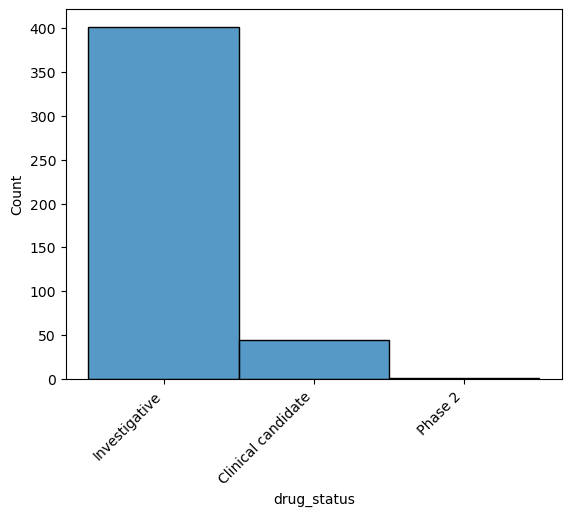

In [23]:
sns.histplot(x=linker['drug_status'])
plt.xticks(rotation=45, ha='right')

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'MCLL0517A'),
  Text(1, 0, 'Lorvotuzumab'),
  Text(2, 0, 'Patritumab'),
  Text(3, 0, 'Cetuximab'),
  Text(4, 0, 'Undisclosed'),
  Text(5, 0, 'J22.9-ISY'),
  Text(6, 0, 'Rosopatamab'),
  Text(7, 0, 'Anti HER2 1-alpha-hydroxyvitamin-D5-HER-2 antibody conjugate mAb')])

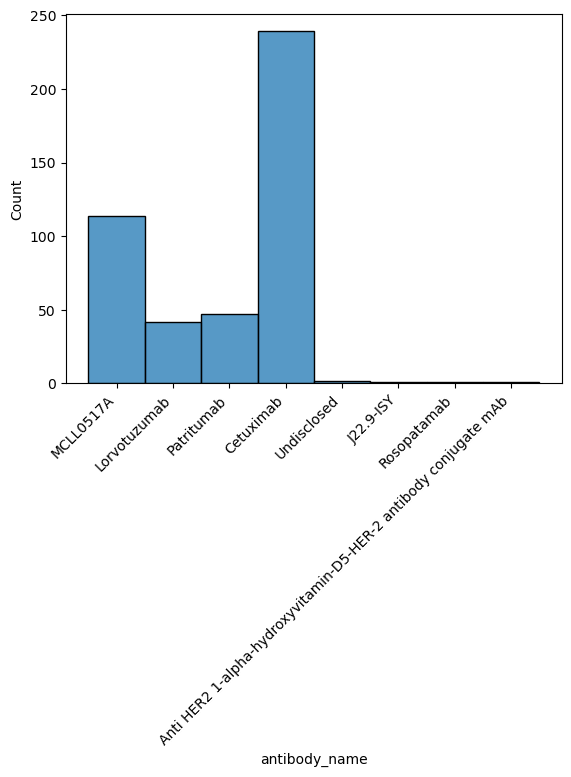

In [24]:
sns.histplot(x=linker['antibody_name'])
plt.xticks(rotation=45, ha='right')

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Cleavable disulfide'),
  Text(1, 0, 'ADC-C1 linker'),
  Text(2, 0, 'Succinimidyl acetylthiopropionate (SATP)'),
  Text(3, 0, 'Mal-Val-Ala-PAB'),
  Text(4, 0, 'Tetraxetan'),
  Text(5, 0, 'Sulfosuccinimidyl 6-4 azido nitrophenylamido hexanode (SANPAH)')])

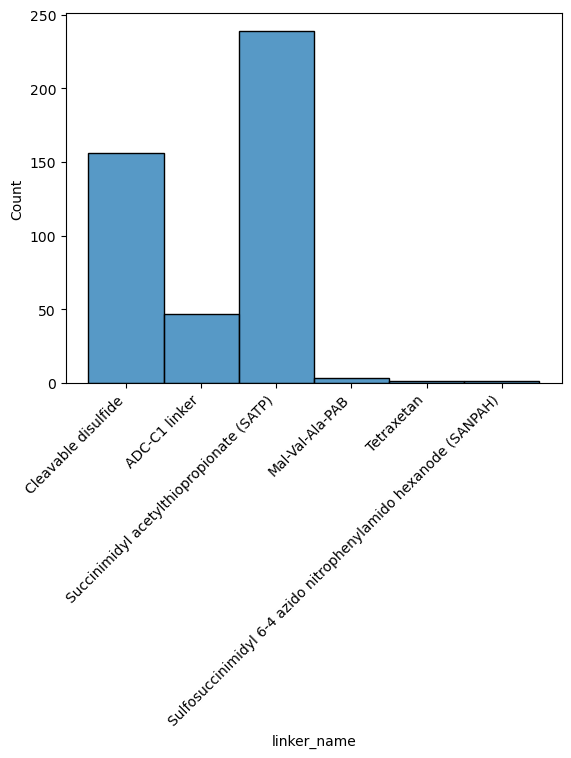

In [25]:
sns.histplot(x=linker['linker_name'])
plt.xticks(rotation=45, ha='right')

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'PBD dimer'),
  Text(1, 0, 'Rachelmycin'),
  Text(2, 0, 'ADC-C1 payload'),
  Text(3, 0, 'Puromycin'),
  Text(4, 0, 'HDP 30.2115'),
  Text(5, 0, 'Y90 (Radioactive isotope)'),
  Text(6, 0, 'Vitamin D')])

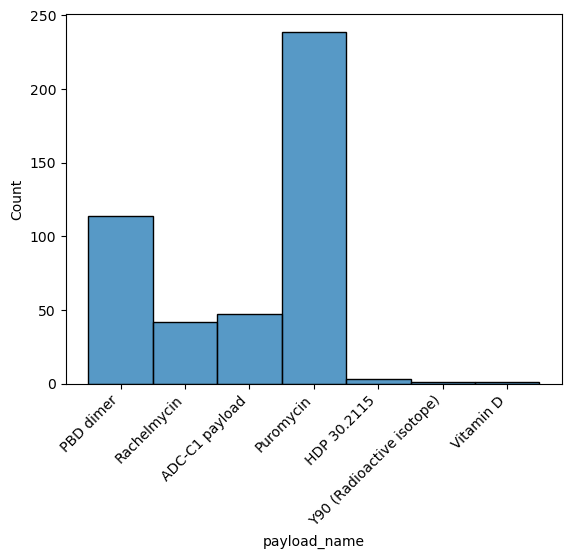

In [26]:
sns.histplot(x=linker['payload_name'])
plt.xticks(rotation=45, ha='right')

In [27]:
linker['K-means'].unique()

array([12,  2,  4,  1,  5,  6,  3,  7, 13, 10,  0,  8, 11])

/home/alex/miniconda3/envs/MSSE_Python/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0.5, 0, 'sqrt(LogP)')

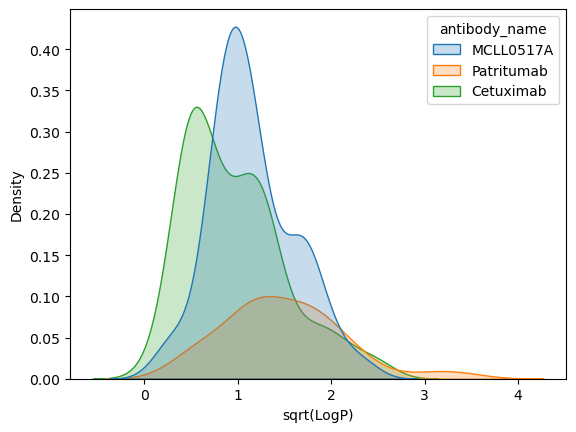

In [38]:
antibody = ['Cetuximab','MCLL0517A','Patritumab']
sns.kdeplot(data=linker[linker['antibody_name'].isin(antibody)], hue='antibody_name', x=np.sqrt(linker['LogP']), fill=True)
plt.xlabel("sqrt(LogP)")

In [ ]:
antibody = ['Cetuximab','MCLL0517A','Patritumab']
sns.kdeplot(data=linker[linker['antibody_name'].isin(antibody)], hue='antibody_name', x=np.sqrt(linker['LogP']), fill=True)
plt.xlabel("sqrt(LogP)")